<a href="https://colab.research.google.com/github/lukita-ctrl/resonancia/blob/main/RLC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cbook
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


f0 = (1091.0318910060735 ± 7.236572292517641) Hz
a = (1.0360945675467395 ± 0.011618864926262172)
r = (69.1830255608348 ± 12.324668869097568)


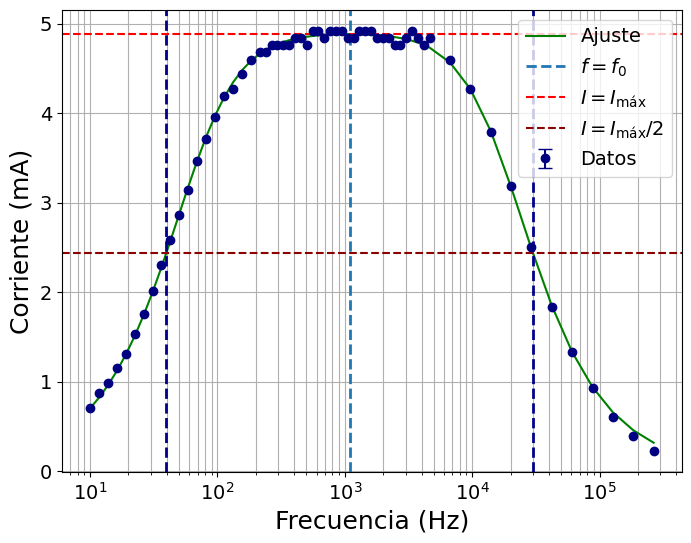

In [ ]:
# Archivo de datos procesados
df = pd.read_csv("Resonancia900 procesado.csv")
df = df[df["Frecuencias"] < 10**(5+1/2)]
df = df.set_index("Frecuencias")

# Parámetros
R = 991.6
error_R = 0.5*R + 0.0003
L = 9.803*(10**(-3))
V = 5
C = 2.155*(10**(-6))

# Valores
f = df.index
w = 2*np.pi*f
T = df['Transferencia']
A = df['Atenuacion']
I = df['Corriente']
error_T = df['Error T']
error_A = df['Error A']
error_Vout = df['Error VCH2']

error_I = np.sqrt(error_Vout**2 - (I*error_R)**2)/R

#===============
# Corriente
#===============

# Ajuste
def ajusteI(f,f0I,a,r):
    return((a*1000)*V/np.sqrt((R+r)**2 + (w*L*(1 - (f0I/f)**2))**2))

# def ajuste_real(f,f0,a,r,c):
#     w0 = 2*np.pi*f0
#     b1 = R*C
#     b2 = R*C*r*c
#     b3 = R*c*(w0**(-2))
#     a1 = b1 + r*(C+c)
#     a2 = b2 + w0**(-2) + L*c
#     return(a*V*np.sqrt((b2**2 + (w*(b1-b3*(w**2)))**2)/((1 - a2*(w**2))**2 + (w*(a1 - b3*(w**2)))**2))/R)

popt,pcov = curve_fit(ajusteI,f,I*1000) # popt: vector de parámetros, pcov: matriz de covarianza (con errores en la diagonal)

# print(popt)
# print(pcov)

f0I = np.abs(popt[0]) # Frecuencia característica
a = popt[1] # Amplitud (sin significado físico)
r = popt[2] # Resistencia interna de la bobina
# c = popt[3] # Capacitancia interna de la bobina
perr = np.sqrt(np.diag(pcov)) # Vector de incertidumbre de cada parámetro
print(f"f0 = ({f0I} ± {perr[0]}) Hz")
print(f"a = ({a} ± {perr[1]})")
print(f"r = ({r} ± {perr[2]})")
# print(f"c = ({c} ± {perr[3]})")

y_fitI = ajusteI(f,f0I,a,r) # Curva de ajuste

# χ²
# chi_sq = (np.sum(((I - y_fit0) / error_T)**2))
# dof = len(f) - len(popt)
# print(f"Chi-cuadrado reducidoDatos procesados RL pa: {chi_sq/dof}")

# Valores característicos de frecuencia y corriente
delta_f = np.sqrt(3)*(R+r)/(4*np.pi*L) # Ancho de banda (semi-diferencia entre f2 y f1)
f1 = np.sqrt(delta_f**2 + f0I**2) - delta_f # Primera frecuencia de medio máximo (I(f1)=I_max/2)
f2 = np.sqrt(delta_f**2 + f0I**2) + delta_f # Segunda frecuencia de medio máximo (I(f2)=I_max/2)

I_max = a*1000*V/(R+r)


# Figura
fig_log, ax1 = plt.subplots(1, figsize=(8,6))

ax1.errorbar(f,I*1000,yerr=error_I,label="Datos", marker="o",linestyle="none",capsize=5, color='navy') # Conjunto de puntos
ax1.plot(f,y_fitI,label="Ajuste", color="g") # Gráfico del ajuste
ax1.set_xlabel("Frecuencia (Hz)", fontsize=18)
ax1.set_ylabel("Corriente (mA)", fontsize=18)
ax1.set_xscale('log')
ax1.axvline(x=np.abs(f0I), linestyle='--', linewidth=2, label="$f=f_0$") # Frecuencia de corte
ax1.axvline(x=f1, linestyle='--', linewidth=2, color="darkblue") # Primera frecuencia de medio máximo
ax1.axvline(x=f2, linestyle='--', linewidth=2, color="darkblue") # Segunda frecuencia de medio máximo
ax1.axhline(y=I_max, linestyle='--', color='r', label=r"$I=I_{\text{máx}}$") # Máximo de corriente
ax1.axhline(y=I_max/2, linestyle='--', color='darkred', label=r"$I=I_{\text{máx}}/2$") # Medio máximo de corriente
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, which="both", ls="-")
ax1.legend(fontsize=14, loc="upper right")
plt.show()


# # Zoom sobre los alrededores de la frecuencia de corte
# axins = inset_axes(ax1, width=1.8, height=2.8, loc='lower right',
#                    bbox_to_anchor=(-0.01, 0.09, 1, 1),
#                    bbox_transform=ax1.transAxes, borderpad=1.5) # Posición del recuadro

# axins.errorbar(f,T,yerr=error_T,marker="o",linestyle="none",capsize=5, markersize=3, color='navy')
# axins.plot(f,y_fit0,color="g")
# axins.set_xlim(17000, 18500) # Rango horizontal del zoom
# axins.set_ylim(0.6, 0.8) # Rango vertical del zoom
# # axins.set_xticks((120,130,140), minor=False)
# axins.set_yticks(np.arange(0.6, 0.8, 0.05), minor=False)
# # #axins.set_xscale('log')
# axins.grid(True, which="both", ls="-")
# axins.tick_params(axis='both', labelsize=14)
# axins.axhline(y=0.7, linestyle='--', color='r')
# axins.axvline(x=18400, linestyle='--', linewidth=2)
# # ax1.indicate_inset_zoom(axins, edgecolor="k", alpha=0)
# mark_inset(ax1, axins, zorder=10, loc1=2, loc2=3, fc="none", ec="k") # Segmentos uniendo el recuadro con la figura

f0P = (1103.693908147149 ± 10.77079355479523) Hz
aP = (0.033169923129937315 ± 0.0002738656671945331)
rP = (82.00770327188661 ± 18.435367671816813)


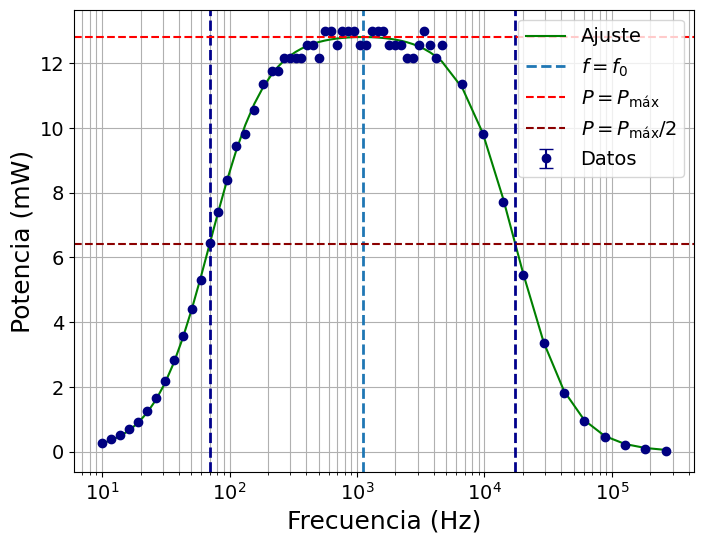

16098.953541765113


In [ ]:
# #===============
# # Potencia
# #===============

P = (R+r)*(I**2)/2
error_P = I*np.sqrt((I*error_R/2)**2 + (R*error_I)**2)

# # Ajuste
# def ajusteP(f,f0P,aP,rP):
#     return(aP*((1000*V)**2)*(R+rP)/(2*(R+rP)**2 + 2*(w*L*(1 - (f0P/f)**2))**2))
def ajusteP(f,f0P,aP,rP):
    return((aP*1000*V)**2/((R+rP)**2 + (w*L*(1 - (f0P/f)**2))**2)*(R+rP)/2)

popt,pcov = curve_fit(ajusteP,f,P*1000) # popt: vector de parámetros, pcov: matriz de covarianza (con errores en la diagonal)

# # print(popt)
# # print(pcov)

f0P = np.abs(popt[0]) # Frecuencia característica
aP = popt[1] # Amplitud (sin significado físico)
rP = popt[2] # Resistencia interna de la bobina
perr = np.sqrt(np.diag(pcov)) # Vector de incertidumbre de cada parámetro
print(f"f0P = ({f0P} ± {perr[0]}) Hz")
print(f"aP = ({aP} ± {perr[1]})")
print(f"rP = ({rP} ± {perr[2]})")

y_fitP = ajusteP(f,f0P,aP,rP) # Curva de ajuste

# # χ²
# chi_sq = (np.sum(((T - y_fit0) / error_T)**2))
# dof = len(f) - len(popt)
# print(f"Chi-cuadrado reducidoDatos procesados RL pa: {chi_sq/dof}")

# Valores característicos de frecuencia y corriente
delta_fP = (R+rP)/(4*np.pi*L) # Ancho de banda (semi-diferencia entre f2 y f1)
f1P = np.sqrt(delta_fP**2 + f0P**2) - delta_fP # Primera frecuencia de medio máximo (I(f1)=I_max/2)
f2P = np.sqrt(delta_fP**2 + f0P**2) + delta_fP # Segunda frecuencia de medio máximo (I(f2)=I_max/2)

P_max = (aP*1000*V)**2/(2*(R+rP))

# Figura
fig_log, ax1 = plt.subplots(1, figsize=(8,6))


ax1.errorbar(f,P*1000,yerr=error_P,label="Datos", marker="o",linestyle="none",capsize=5, color='navy') # Conjunto de puntos
ax1.plot(f,y_fitP,label="Ajuste", color="g") # Gráfico del ajuste
ax1.set_xlabel("Frecuencia (Hz)", fontsize=18)
ax1.set_ylabel("Potencia (mW)", fontsize=18)
# ax1.set_yticks((0,0.2,0.4,0.6,0.7,0.8,1))
ax1.set_xscale('log')
ax1.axvline(x=f0P, linestyle='--', linewidth=2, label="$f=f_0$")
ax1.axvline(x=f1P, linestyle='--', linewidth=2, color="darkblue")
ax1.axvline(x=f2P, linestyle='--', linewidth=2, color="darkblue")
ax1.axhline(y=P_max, linestyle='--', color='red', label=r"$P = P_\text{máx}$")
ax1.axhline(y=P_max/2, linestyle='--', color='darkred', label=r"$P = P_\text{máx}/2$")
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, which="both", ls="-")
ax1.legend(fontsize=14, loc="upper right")
plt.show()
print(R/(2*np.pi*L))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Ahora puedes acceder a tus archivos en '/content/drive/My Drive/'
# Por ejemplo, para guardar un archivo:
# with open('/content/drive/My Drive/mi_archivo_guardado.txt', 'w') as f:
#   f.write('¡Hola desde Colab guardado en Drive!')

# Y para leerlo:
# with open('/content/drive/My Drive/mi_archivo_guardado.txt', 'r') as f:
#   contenido = f.read()
# print(contenido)

#### Otras opciones para guardar archivos:

*   **GitHub:** Puedes guardar tus notebooks y otros archivos en un repositorio de GitHub. Colab se integra bien con GitHub.
*   **Descargar localmente:** Si el archivo es pequeño, puedes descargarlo a tu computadora local usando `files.download()` de `google.colab.files`.

La opción de Google Drive es generalmente la más práctica para trabajar con datos y resultados generados durante una sesión de Colab.

### Cómo integrar Google Colab con GitHub

Google Colab permite una integración directa con GitHub, lo que facilita guardar y cargar notebooks (`.ipynb`) directamente desde tus repositorios. Esto es ideal para el control de versiones y para compartir tu trabajo.

#### Opciones principales:

1.  **Guardar una copia en GitHub:** Desde Colab, puedes ir a `Archivo > Guardar una copia en GitHub...`. Esto te pedirá que inicies sesión en GitHub (si no lo has hecho ya) y elijas el repositorio y la ruta donde quieres guardar el notebook.

2.  **Abrir un notebook de GitHub:** Puedes abrir un notebook existente desde GitHub yendo a `Archivo > Abrir notebook...` y seleccionando la pestaña de GitHub.

3.  **Configurar credenciales de Git para operaciones más avanzadas:** Para operaciones más avanzadas (como `git push`, `git pull`, `git commit` directamente desde una celda de código), necesitarás configurar tus credenciales de Git dentro de Colab. Esto generalmente implica usar tokens de acceso personal de GitHub.

Aquí hay un ejemplo básico de cómo podrías interactuar con Git dentro de Colab si ya tienes un repositorio clonado (aunque la opción de 'Guardar una copia en GitHub' es la más sencilla para notebooks):

In [ ]:
# Este es un ejemplo para interactuar con git si ya tienes un repositorio clonado o quieres clonar uno nuevo.
# Para la mayoría de los casos de guardar notebooks, usa la opción de menú 'Archivo > Guardar una copia en GitHub...'

# Puedes clonar un repositorio (esto lo haría una vez por sesión o si el repo no está ya)
# !git clone https://github.com/tu_usuario/tu_repositorio.git

# Moverte al directorio del repositorio (si lo has clonado)
# import os
# os.chdir('tu_repositorio')

# Configurar tu nombre de usuario y correo electrónico (necesario para hacer commits)
# !git config --global user.name 'Tu Nombre'
# !git config --global user.email 'tu_email@example.com'

# Hacer un commit y push (esto requeriría un token de acceso personal si el repo es privado o para evitar introducir la contraseña cada vez)
# !git add .
# !git commit -m 'Actualización desde Colab'
# !git push https://tu_token_acceso_personal@github.com/tu_usuario/tu_repositorio.git master

print("Para guardar tu notebook actual, la forma más fácil es ir a 'Archivo > Guardar una copia en GitHub...'")